In [1]:
# A1 - Project Root Setup

from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().parent

os.chdir(
    PROJECT_ROOT
)

print()

print(
    "PROJECT_ROOT:",
    PROJECT_ROOT
)

assert (
    PROJECT_ROOT / "configs"
).exists()

assert (
    PROJECT_ROOT / "src"
).exists()

print(
    "Project structure verified."
)


PROJECT_ROOT: d:\IITG\Projects\audio_factor_disentanglement_v2
Project structure verified.


In [2]:
# A2 - Imports

import os
import gc
import copy
import json
import yaml
import random
import warnings
import pickle

from pathlib import Path

import numpy as np
import pandas as pd

import torch

import matplotlib.pyplot as plt

from src.utils.config_loader import (
    load_yaml
)

from src.dataset.feature_loader import (
    build_dataloader
)

from src.trainers.checkpoint_manager import (
    CheckpointManager
)

from src.models.factorized.factorized_vae import (
    FactorizedVAE
)

warnings.filterwarnings(
    "ignore"
)

print()

print(
    "Imports Ready"
)


Imports Ready


In [3]:
# A3 - Device Setup

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else

    "cpu"
)

print()

print(
    "Device:",
    device
)

if torch.cuda.is_available():

    print()

    print(
        torch.cuda.get_device_name(0)
    )


Device: cpu


In [4]:
# A4 - Select Training Run

RUN_NAME = "factorized_vae_20260622_185710"

RUN_DIR = (

    PROJECT_ROOT

    /

    "outputs"

    /

    "runs"

    /

    RUN_NAME
)

print()

print(
    RUN_DIR
)

assert RUN_DIR.exists()


d:\IITG\Projects\audio_factor_disentanglement_v2\outputs\runs\factorized_vae_20260622_185710


In [5]:
# A5 - Load Frozen Configurations

CONFIG_DIR = (

    RUN_DIR

    /

    "configs"
)

with open(

    CONFIG_DIR

    /

    "model_config.yaml"

) as f:

    model_cfg = yaml.safe_load(f)

with open(

    CONFIG_DIR

    /

    "train_config.yaml"

) as f:

    train_cfg = yaml.safe_load(f)

with open(

    CONFIG_DIR

    /

    "feature_config.yaml"

) as f:

    feature_cfg = yaml.safe_load(f)

print()

print(
    "Frozen Configurations Loaded"
)


Frozen Configurations Loaded


In [6]:
# A6 - Build Runtime Configuration

merged_cfg = copy.deepcopy(
    model_cfg
)

merged_cfg[
    "training"
] = train_cfg[
    "training"
]

merged_cfg[
    "gradient"
] = train_cfg[
    "gradient"
]

merged_cfg[
    "mixed_precision"
] = train_cfg[
    "mixed_precision"
]

merged_cfg[
    "staged_activation"
] = train_cfg[
    "staged_activation"
]

merged_cfg[
    "early_stopping"
] = train_cfg[
    "early_stopping"
]

print()

print(
    "Merged Runtime Configuration Ready"
)


Merged Runtime Configuration Ready


In [7]:
# A7 - Analysis Output Directories

ANALYSIS_ROOT = (

    PROJECT_ROOT

    /

    "data"

    /

    "analysis_outputs"
)

DECODER_DIR = (

    ANALYSIS_ROOT

    /

    "decoder_outputs"
)

LATENT_DIR = (

    ANALYSIS_ROOT

    /

    "latents"
)

SWAP_DIR = (

    ANALYSIS_ROOT

    /

    "swaps"
)

TEMP_AUDIO_DIR = (

    ANALYSIS_ROOT

    /

    "temporary_audio"
)

PLOT_DIR = (

    ANALYSIS_ROOT

    /

    "plots"
)

REPORT_DIR = (

    ANALYSIS_ROOT

    /

    "reports"
)

for folder in [

    ANALYSIS_ROOT,

    DECODER_DIR,

    LATENT_DIR,

    SWAP_DIR,

    TEMP_AUDIO_DIR,

    PLOT_DIR,

    REPORT_DIR

]:

    folder.mkdir(

        parents=True,

        exist_ok=True
    )

print()

print(
    ANALYSIS_ROOT
)


d:\IITG\Projects\audio_factor_disentanglement_v2\data\analysis_outputs


In [8]:
# A8 - Test Feature Directories

S1_TEST_DIR = (

    PROJECT_ROOT

    /

    "data"

    /

    "features"

    /

    "s1"

    /

    "s1_test_clean"
)

S2_TEST_DIR = (

    PROJECT_ROOT

    /

    "data"

    /

    "features"

    /

    "s2"

    /

    "s2_test_noisy"
)

print()

print(
    S1_TEST_DIR
)

print(
    S2_TEST_DIR
)


d:\IITG\Projects\audio_factor_disentanglement_v2\data\features\s1\s1_test_clean
d:\IITG\Projects\audio_factor_disentanglement_v2\data\features\s2\s2_test_noisy


In [9]:
# A9 - Checkpoint Paths

CHECKPOINT_DIR = (

    RUN_DIR

    /

    "checkpoints"
)

BEST_CHECKPOINT = (

    CHECKPOINT_DIR

    /

    "best.pt"
)

LATEST_CHECKPOINT = (

    CHECKPOINT_DIR

    /

    "latest.pt"
)

print()

print(
    BEST_CHECKPOINT
)

assert BEST_CHECKPOINT.exists()


d:\IITG\Projects\audio_factor_disentanglement_v2\outputs\runs\factorized_vae_20260622_185710\checkpoints\best.pt


In [10]:
# B1 - Build Model

model = FactorizedVAE(
    merged_cfg
).to(
    device
)

print()

print(
    type(model)
)


<class 'src.models.factorized.factorized_vae.FactorizedVAE'>


In [11]:
# B2 - Build Checkpoint Manager

checkpoint_manager = CheckpointManager(

    PROJECT_ROOT,

    checkpoint_dir=CHECKPOINT_DIR
)

print()

print(
    checkpoint_manager.checkpoint_dir
)


d:\IITG\Projects\audio_factor_disentanglement_v2\outputs\runs\factorized_vae_20260622_185710\checkpoints


In [12]:
# B3 - Restore Best Checkpoint

checkpoint = checkpoint_manager.resume(

    BEST_CHECKPOINT,

    model=model
)

print()

print(
    "Checkpoint Loaded"
)

print()

print(
    "Epoch:",
    checkpoint["epoch"]
)

print()

print(
    "Validation Loss:",
    checkpoint["metrics"]["total"]
)


Checkpoint Loaded

Epoch: 234

Validation Loss: 6.27838601236758


In [13]:
# B4 - Evaluation Mode

model.eval()

torch.set_grad_enabled(
    False
)

print()

print(
    "Evaluation Mode Enabled"
)


Evaluation Mode Enabled


In [14]:
# B5 - Build Test Loader

test_loader = build_dataloader(

    PROJECT_ROOT,

    split="test"
)

print()

print(
    "Test Batches:",
    len(test_loader)
)


Test Batches: 11


In [15]:
# B6 - Load Test Batch

test_batch = next(

    iter(
        test_loader
    )
)

test_batch = {

    k:

    v.to(device)

    if torch.is_tensor(v)

    else v

    for k,v

    in test_batch.items()

}

print()

print(
    "Test Batch Loaded"
)


Test Batch Loaded


In [17]:
# B7 - Inspect Test Batch

print()

for k,v in test_batch.items():

    if torch.is_tensor(v):

        print(

            f"{k:<20}",

            tuple(v.shape)

        )

    else:

        print(

            f"{k:<20}",

            v
        )


logmel               (2, 80, 63)
mr_mag_256           (2, 129, 125)
mr_mag_512           (2, 257, 63)
mr_mag_1024          (2, 513, 32)
magnitude            (2, 513, 63)
if                   (2, 513, 63)
modgd                (2, 513, 63)
phase_sin            (2, 513, 63)
phase_cos            (2, 513, 63)
lengths              (2,)
speaker              ['s1', 's1']
condition            ['clean', 'clean']
split                ['test', 'test']


In [18]:
# B9 - Forward Pass

with torch.no_grad():

    outputs = model(
        test_batch
    )

print()

print(
    "Forward Pass Complete"
)


Forward Pass Complete


In [19]:
# B10 - Inspect Forward Outputs

for k,v in outputs.items():

    if torch.is_tensor(v):

        print(

            f"{k:<25}",

            tuple(v.shape)

        )

    elif isinstance(

        v,

        dict

    ):

        print()

        print(k)

        for kk,vv in v.items():

            if torch.is_tensor(vv):

                print(

                    f"  {kk:<20}",

                    tuple(vv.shape)

                )


groups

latents
  content              (2, 64)
  speaker              (2, 64)
  environment          (2, 96)
  excitation           (2, 32)
  fidelity             (2, 128)

mu
  content              (2, 64)
  speaker              (2, 64)
  environment          (2, 96)
  excitation           (2, 32)
  fidelity             (2, 128)

logvar
  content              (2, 64)
  speaker              (2, 64)
  environment          (2, 96)
  excitation           (2, 32)
  fidelity             (2, 128)

reconstructions
  logmel               (2, 80, 63)
  mr_mag_256           (2, 129, 125)
  mr_mag_512           (2, 257, 63)
  magnitude            (2, 513, 63)
  mr_mag_1024          (2, 513, 32)
  if                   (2, 513, 63)
  modgd                (2, 513, 63)
  phase_sin            (2, 513, 63)
  phase_cos            (2, 513, 63)
joint_latent              (2, 384)


In [20]:
# G2 - Load Entire Test Recordings

import numpy as np
from pathlib import Path

FEATURE_NAMES = [

    "logmel",

    "mr_mag_256",
    "mr_mag_512",
    "mr_mag_1024",

    "magnitude",

    "if",

    "modgd",

    "phase_sin",
    "phase_cos"
]


def load_recording(recording_dir):

    recording = []

    fragment_dirs = sorted(

        recording_dir.glob(
            "fragment_*"
        )
    )

    for fragment_dir in fragment_dirs:

        fragment = {}

        for feature in FEATURE_NAMES:

            fragment[feature] = torch.tensor(

                np.load(

                    fragment_dir
                    /
                    f"{feature}.npy"
                ),

                dtype=torch.float32
            )

        fragment["fragment_name"] = fragment_dir.name

        recording.append(fragment)

    return recording


s1_recording = load_recording(
    S1_TEST_DIR
)

s2_recording = load_recording(
    S2_TEST_DIR
)

print()

print(
    "S1 Fragments:",
    len(s1_recording)
)

print(
    "S2 Fragments:",
    len(s2_recording)
)


S1 Fragments: 9
S2 Fragments: 12


In [21]:
# G3 - Inspect Recording Shapes

print()

print("S1")

for k,v in s1_recording[0].items():

    if torch.is_tensor(v):

        print(
            f"{k:<20}",
            tuple(v.shape)
        )

print()

print("S2")

for k,v in s2_recording[0].items():

    if torch.is_tensor(v):

        print(
            f"{k:<20}",
            tuple(v.shape)
        )


S1
logmel               (80, 43)
mr_mag_256           (129, 85)
mr_mag_512           (257, 43)
mr_mag_1024          (513, 22)
magnitude            (513, 43)
if                   (513, 43)
modgd                (513, 43)
phase_sin            (513, 43)
phase_cos            (513, 43)

S2
logmel               (80, 39)
mr_mag_256           (129, 77)
mr_mag_512           (257, 39)
mr_mag_1024          (513, 20)
magnitude            (513, 39)
if                   (513, 39)
modgd                (513, 39)
phase_sin            (513, 39)
phase_cos            (513, 39)


In [22]:
# G4 - Prepare Single Fragment Batch

def fragment_to_batch(fragment):

    batch = {}

    for k,v in fragment.items():

        if torch.is_tensor(v):

            batch[k] = (

                v
                .unsqueeze(0)
                .to(device)
            )

    return batch


s1_fragment = fragment_to_batch(

    s1_recording[0]
)

s2_fragment = fragment_to_batch(

    s2_recording[0]
)

print()

print(
    "Single Fragment Batches Ready"
)


Single Fragment Batches Ready


In [23]:
# G5 - Encode First Fragment

with torch.no_grad():

    s1_encoded = model(
        s1_fragment
    )

    s2_encoded = model(
        s2_fragment
    )

print()

print(
    "Encoding Complete"
)


Encoding Complete


In [24]:
# G6 - Inspect Latent Groups

for name, encoded in [

    ("S1", s1_encoded),

    ("S2", s2_encoded)

]:

    print()

    print("=" * 80)

    print(name)

    print("=" * 80)

    for k,v in encoded["latents"].items():

        print(

            f"{k:<20}",

            tuple(v.shape)
        )


S1
content              (1, 64)
speaker              (1, 64)
environment          (1, 96)
excitation           (1, 32)
fidelity             (1, 128)

S2
content              (1, 64)
speaker              (1, 64)
environment          (1, 96)
excitation           (1, 32)
fidelity             (1, 128)


In [25]:
# G7 - Inspect Decoder Outputs

for feature, tensor in s1_encoded["reconstructions"].items():

    print(

        f"{feature:<20}",

        tuple(tensor.shape)
    )

logmel               (1, 80, 43)
mr_mag_256           (1, 129, 85)
mr_mag_512           (1, 257, 43)
magnitude            (1, 513, 43)
mr_mag_1024          (1, 513, 22)
if                   (1, 513, 43)
modgd                (1, 513, 43)
phase_sin            (1, 513, 43)
phase_cos            (1, 513, 43)


In [27]:
# G8 - Save Original Decoder Outputs

ORIGINAL_OUTPUT_DIR = (

    ANALYSIS_ROOT

    /

    "original_decoder_outputs"
)

ORIGINAL_OUTPUT_DIR.mkdir(

    parents=True,

    exist_ok=True
)

for feature, tensor in s1_encoded["reconstructions"].items():

    np.save(

        ORIGINAL_OUTPUT_DIR

        /

        f"s1_{feature}.npy",

        tensor.squeeze(0)

        .cpu()

        .numpy()
    )

for feature, tensor in s2_encoded["reconstructions"].items():

    np.save(

        ORIGINAL_OUTPUT_DIR

        /

        f"s2_{feature}.npy",

        tensor.squeeze(0)

        .cpu()

        .numpy()
    )

print()

print(
    "Decoder Outputs Saved"
)


Decoder Outputs Saved


In [28]:
# G8 - Reconstruction Metrics

import torch.nn.functional as F

reconstruction_metrics = {}

for feature in FEATURE_NAMES:

    original = s1_fragment[feature]

    reconstructed = s1_encoded["reconstructions"][feature]

    reconstruction_metrics[feature] = {

        "l1":

            F.l1_loss(

                reconstructed,

                original

            ).item(),

        "mse":

            F.mse_loss(

                reconstructed,

                original

            ).item()

    }

print()

for feature, metric in reconstruction_metrics.items():

    print(

        f"{feature:<18}",

        f"L1={metric['l1']:.6f}",

        f"MSE={metric['mse']:.6f}"

    )


logmel             L1=0.170075 MSE=0.041263
mr_mag_256         L1=0.166046 MSE=0.040432
mr_mag_512         L1=0.159850 MSE=0.037766
mr_mag_1024        L1=0.151295 MSE=0.034097
magnitude          L1=0.149457 MSE=0.033434
if                 L1=0.297448 MSE=0.427186
modgd              L1=0.849538 MSE=0.805129
phase_sin          L1=0.632335 MSE=0.496127
phase_cos          L1=0.640014 MSE=0.504242


In [30]:
# G9 - Save Reconstruction Metrics

metrics_df = pd.DataFrame(

    reconstruction_metrics

).T

metrics_df.to_csv(

    ANALYSIS_ROOT

    /

    "fragment_reconstruction_metrics.csv"
)

metrics_df

,l1,mse
logmel,0.170075,0.041263
mr_mag_256,0.166046,0.040432
mr_mag_512,0.159850,0.037766
mr_mag_1024,0.151295,0.034097
magnitude,0.149457,0.033434
if,0.297448,0.427186
modgd,0.849538,0.805129
phase_sin,0.632335,0.496127
phase_cos,0.640014,0.504242


In [31]:
# G10 - Latent Statistics

latent_statistics = {}

for group, latent in s1_encoded["latents"].items():

    latent = latent.squeeze(0).cpu()

    latent_statistics[group] = {

        "mean":

            latent.mean().item(),

        "std":

            latent.std().item(),

        "min":

            latent.min().item(),

        "max":

            latent.max().item(),

        "variance":

            latent.var().item()

    }

pd.DataFrame(

    latent_statistics

).T

,mean,std,min,max,variance
content,-0.121799,1.629387,-4.992096,3.473607,2.654901
speaker,0.090268,0.908081,-1.493684,2.795181,0.824610
environment,-0.203616,1.150625,-3.581153,2.912488,1.323939
excitation,0.156687,0.905927,-2.240889,1.732757,0.820703
fidelity,-0.004524,1.338408,-3.808911,3.015410,1.791336


In [33]:
# G11 - Save Latent Statistics

pd.DataFrame(

    latent_statistics

).T.to_csv(

    ANALYSIS_ROOT

    /

    "latent_statistics.csv"
)

print(

    "Latent Statistics Saved"
)

Latent Statistics Saved


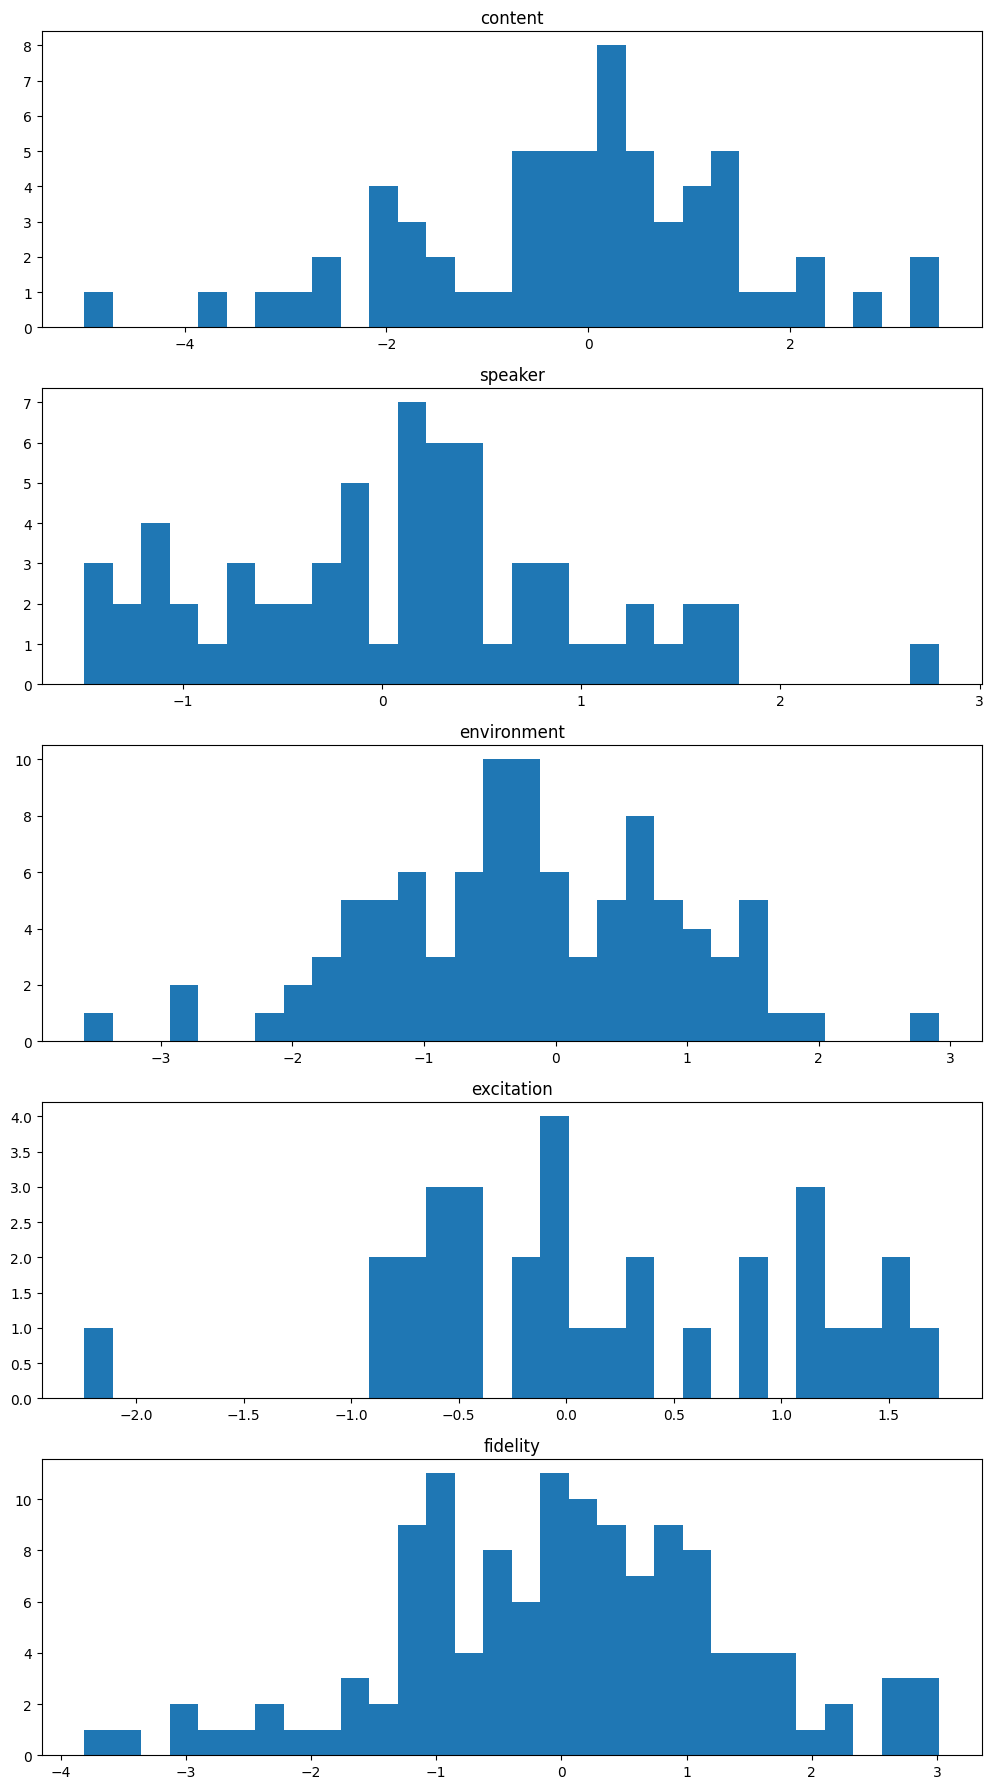

In [34]:
# G12 - Latent Histograms

fig, axes = plt.subplots(

    5,

    1,

    figsize=(10,18)
)

for ax,(group,latent) in zip(

    axes,

    s1_encoded["latents"].items()

):

    ax.hist(

        latent.squeeze()

        .cpu()

        .numpy(),

        bins=30

    )

    ax.set_title(group)

plt.tight_layout()

In [35]:
# G13 - Save Histogram Figure

plt.savefig(

    ANALYSIS_ROOT

    /

    "latent_histograms.png",

    dpi=300,

    bbox_inches="tight"
)

print(

    "Histogram Saved"
)

Histogram Saved


<Figure size 640x480 with 0 Axes>

In [36]:
# G14 - Encode All Test Fragments

def encode_recording(recording):

    encoded = []

    with torch.no_grad():

        for fragment in recording:

            batch = {}

            for k,v in fragment.items():

                if torch.is_tensor(v):

                    batch[k] = (

                        v.unsqueeze(0)
                        .to(device)
                    )

            outputs = model(batch)

            encoded.append(outputs)

    return encoded


s1_encoded_all = encode_recording(
    s1_recording
)

s2_encoded_all = encode_recording(
    s2_recording
)

print()

print(
    "Encoded S1:",
    len(s1_encoded_all)
)

print(
    "Encoded S2:",
    len(s2_encoded_all)
)


Encoded S1: 9
Encoded S2: 12


In [37]:
# G15 - Build Latent Database

latent_database = []

for recording_name, encoded_list in [

    ("s1_test_clean", s1_encoded_all),

    ("s2_test_noisy", s2_encoded_all)

]:

    for fragment_id, outputs in enumerate(encoded_list):

        row = {

            "recording": recording_name,

            "fragment": fragment_id

        }

        for group, latent in outputs["latents"].items():

            row[group] = (

                latent

                .squeeze(0)

                .cpu()

                .numpy()
            )

        latent_database.append(row)

print()

print(
    "Total Fragments:",
    len(latent_database)
)


Total Fragments: 21


In [38]:
# G16 - Stack Latents

latent_arrays = {}

for group in [

    "content",

    "speaker",

    "environment",

    "excitation",

    "fidelity"

]:

    latent_arrays[group] = np.stack(

        [

            row[group]

            for row

            in latent_database

        ]

    )

for k,v in latent_arrays.items():

    print(

        f"{k:<15}",

        v.shape
    )

content         (21, 64)
speaker         (21, 64)
environment     (21, 96)
excitation      (21, 32)
fidelity        (21, 128)


In [39]:
# G17 - Save Latent Database

import pickle

with open(

    ANALYSIS_ROOT

    /

    "latent_database.pkl",

    "wb"

) as f:

    pickle.dump(

        latent_database,

        f
    )

print()

print(
    "Latent Database Saved"
)


Latent Database Saved


In [41]:
# G18 - PCA Analysis

from sklearn.decomposition import PCA

PCA_DIR = ANALYSIS_ROOT / "pca"

PCA_DIR.mkdir(

    parents=True,

    exist_ok=True
)

pca_results = {}

for group, latent in latent_arrays.items():

    pca = PCA(

        n_components=2,

        random_state=42
    )

    coords = pca.fit_transform(
        latent
    )

    pca_results[group] = {

        "coords": coords,

        "variance":

            pca.explained_variance_ratio_
    }

    plt.figure(

        figsize=(6,6)
    )

    colors = [

        "tab:blue"

        if row["recording"] == "s1_test_clean"

        else

        "tab:red"

        for row in latent_database
    ]

    plt.scatter(

        coords[:,0],

        coords[:,1],

        c=colors,

        s=60
    )

    plt.title(

        f"{group} PCA"
    )

    plt.xlabel("PC1")

    plt.ylabel("PC2")

    plt.tight_layout()

    plt.savefig(

        PCA_DIR /

        f"{group}_pca.png",

        dpi=300
    )

    plt.close()

print(
    "PCA Complete"
)

PCA Complete


In [42]:
# G19 - t-SNE Analysis

from sklearn.manifold import TSNE

TSNE_DIR = ANALYSIS_ROOT / "tsne"

TSNE_DIR.mkdir(

    parents=True,

    exist_ok=True
)

tsne_results = {}

for group, latent in latent_arrays.items():

    embedding = TSNE(

        n_components=2,

        perplexity=5,

        random_state=42,

        init="pca"

    ).fit_transform(

        latent
    )

    tsne_results[group] = embedding

    plt.figure(

        figsize=(6,6)
    )

    colors = [

        "tab:blue"

        if row["recording"] == "s1_test_clean"

        else

        "tab:red"

        for row in latent_database
    ]

    plt.scatter(

        embedding[:,0],

        embedding[:,1],

        c=colors,

        s=60
    )

    plt.title(

        f"{group} t-SNE"
    )

    plt.tight_layout()

    plt.savefig(

        TSNE_DIR /

        f"{group}_tsne.png",

        dpi=300
    )

    plt.close()

print(
    "t-SNE Complete"
)

t-SNE Complete


In [43]:
# G20 - Correlation Matrix

CORR_DIR = ANALYSIS_ROOT / "correlations"

CORR_DIR.mkdir(

    parents=True,

    exist_ok=True
)

for group, latent in latent_arrays.items():

    corr = np.corrcoef(

        latent,

        rowvar=False
    )

    plt.figure(

        figsize=(8,8)
    )

    plt.imshow(

        corr,

        cmap="coolwarm",

        vmin=-1,

        vmax=1
    )

    plt.colorbar()

    plt.title(

        group
    )

    plt.tight_layout()

    plt.savefig(

        CORR_DIR /

        f"{group}_correlation.png",

        dpi=300
    )

    plt.close()

print(
    "Correlation Matrices Saved"
)

Correlation Matrices Saved


In [44]:
# G21 - KL Statistics

kl_summary = {}

for group in [

    "content",

    "speaker",

    "environment",

    "excitation",

    "fidelity"

]:

    mu = np.stack([

        outputs["mu"][group]

        .cpu()

        .numpy()

        .squeeze()

        for outputs

        in (

            s1_encoded_all

            +

            s2_encoded_all
        )

    ])

    logvar = np.stack([

        outputs["logvar"][group]

        .cpu()

        .numpy()

        .squeeze()

        for outputs

        in (

            s1_encoded_all

            +

            s2_encoded_all
        )

    ])

    kl = -0.5 * (

        1

        +

        logvar

        -

        mu**2

        -

        np.exp(logvar)

    )

    kl_summary[group] = kl.mean(axis=0)

pd.DataFrame(

    kl_summary

).to_csv(

    ANALYSIS_DIR

    /

    "kl_per_dimension.csv",

    index=False
)

print(
    "KL Saved"
)

ValueError: All arrays must be of the same length